In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load dataset
df = pd.read_csv("housing.csv")

# Show first 5 rows
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
# Missing values
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [5]:
# Statistics
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
# Fill missing values with median
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

/tmp/ipykernel_4362/3690399748.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


In [7]:
# Convert categorical data into numerical
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

In [8]:
# Separate features and target
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

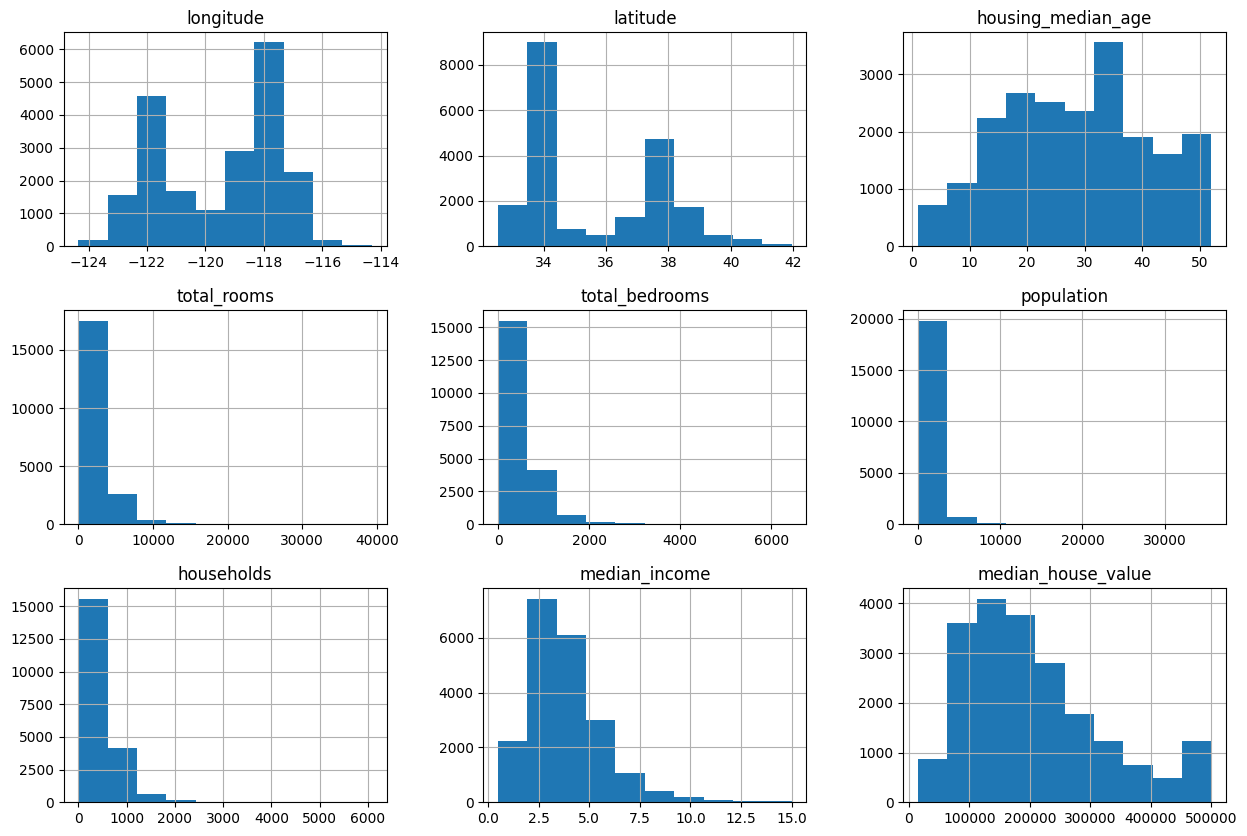

In [9]:
# Histograms
df.hist(figsize=(15,10))
plt.show()

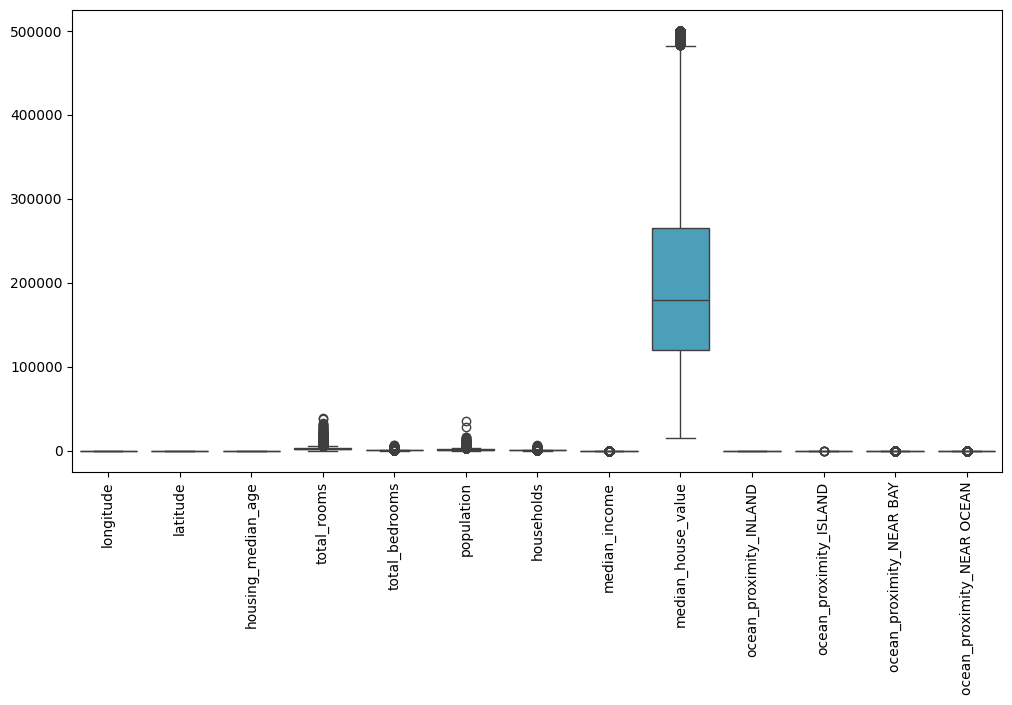

In [10]:
# Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

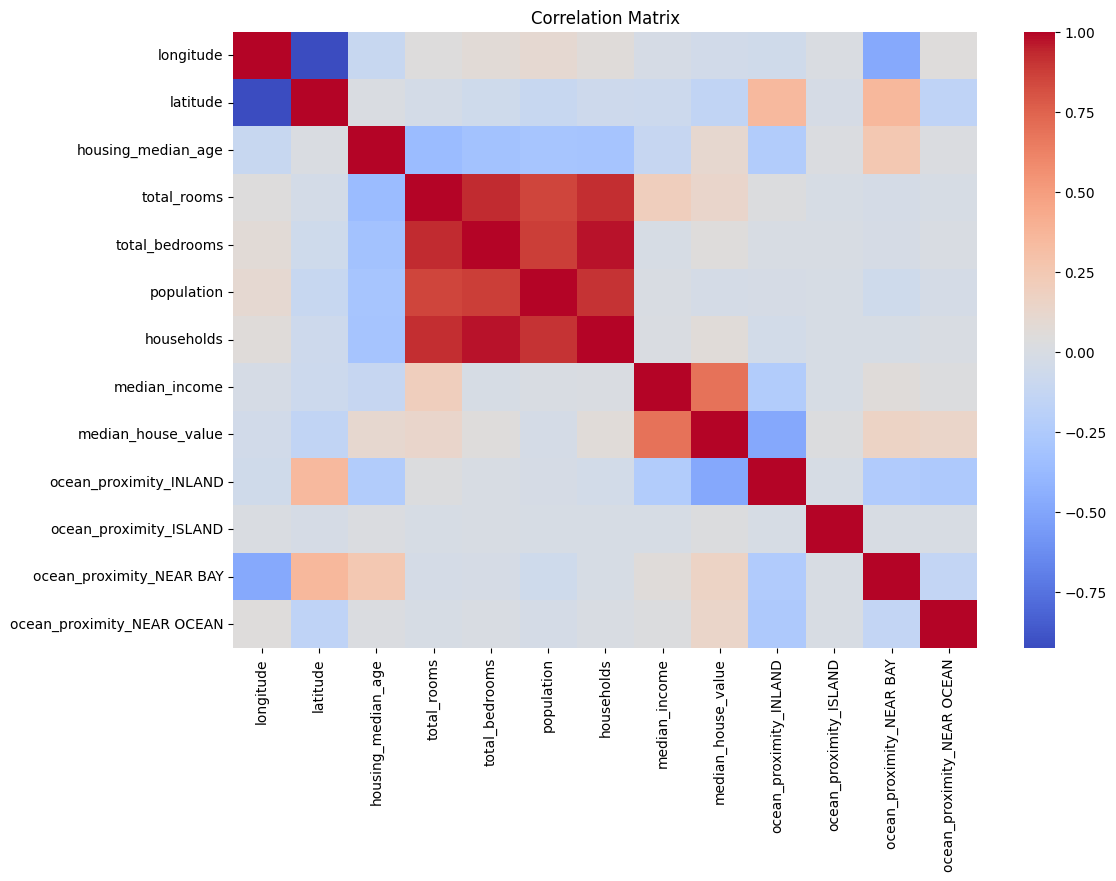

In [11]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Linear Regression
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train, y_train)

# Predictions
linear_pred = linear_model.predict(X_test)

In [14]:
# Polynomial Features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
poly_pred = poly_model.predict(X_test_poly)

In [15]:
# Decision Tree
tree_model = DecisionTreeRegressor(random_state=42)

# Train
tree_model.fit(X_train, y_train)

# Predictions
tree_pred = tree_model.predict(X_test)

In [16]:
# Random Forest
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
forest_model.fit(X_train, y_train)

# Predictions
forest_pred = forest_model.predict(X_test)

In [17]:
# Evaluation function
def evaluate_model(y_test, predictions, model_name):

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    print(f"{model_name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    print("-------------------------")

In [18]:
# Evaluate models
evaluate_model(y_test, linear_pred, "Linear Regression")

evaluate_model(y_test, poly_pred, "Polynomial Regression")

evaluate_model(y_test, tree_pred, "Decision Tree Regression")

evaluate_model(y_test, forest_pred, "Random Forest Regression")

Linear Regression
MAE: 50670.73824097191
MSE: 4908476721.156616
R2 Score: 0.6254240620553606
-------------------------
Polynomial Regression
MAE: 46394.76438853572
MSE: 4511449290.397701
R2 Score: 0.6557220405759203
-------------------------
Decision Tree Regression
MAE: 44214.67223837209
MSE: 4870669661.1838665
R2 Score: 0.6283091964371093
-------------------------
Random Forest Regression
MAE: 31642.75753633721
MSE: 2404389528.630863
R2 Score: 0.8165160977560968
-------------------------


In [19]:
# Create comparison table

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "R2 Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, poly_pred),
        r2_score(y_test, tree_pred),
        r2_score(y_test, forest_pred)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.625424
1,Polynomial Regression,0.655722
2,Decision Tree,0.628309
3,Random Forest,0.816516


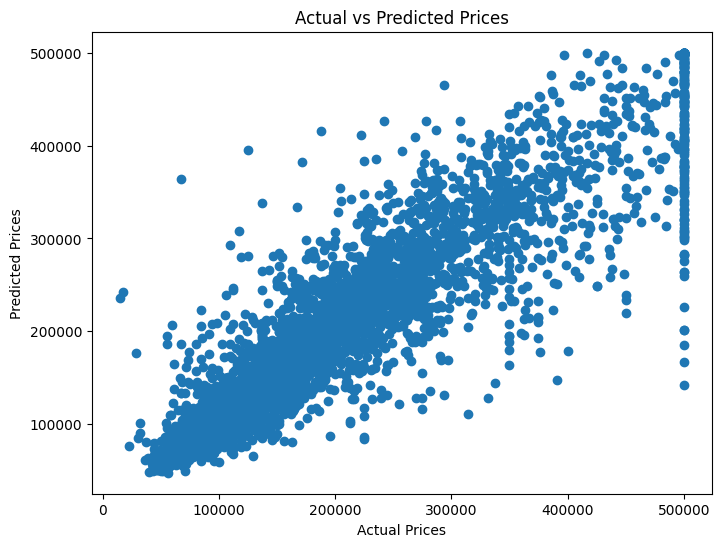

In [20]:
# Prediction vs Actual
plt.figure(figsize=(8,6))

plt.scatter(y_test, forest_pred)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

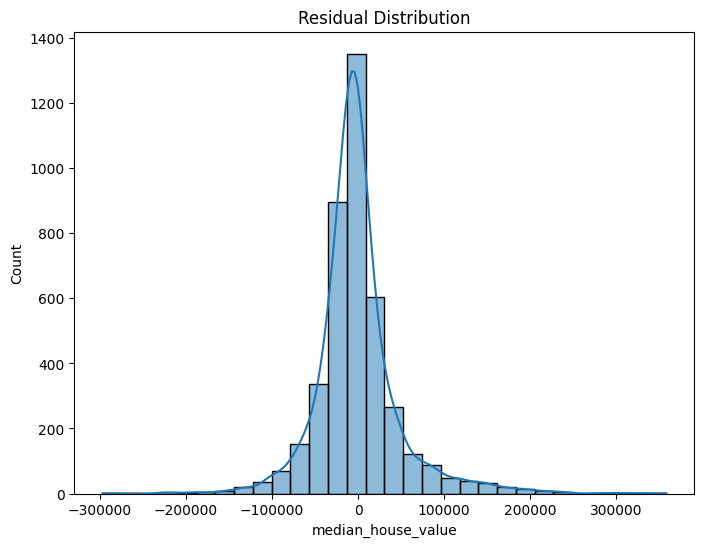

In [21]:
# Residuals
residuals = y_test - forest_pred

# Histogram
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")

plt.show()

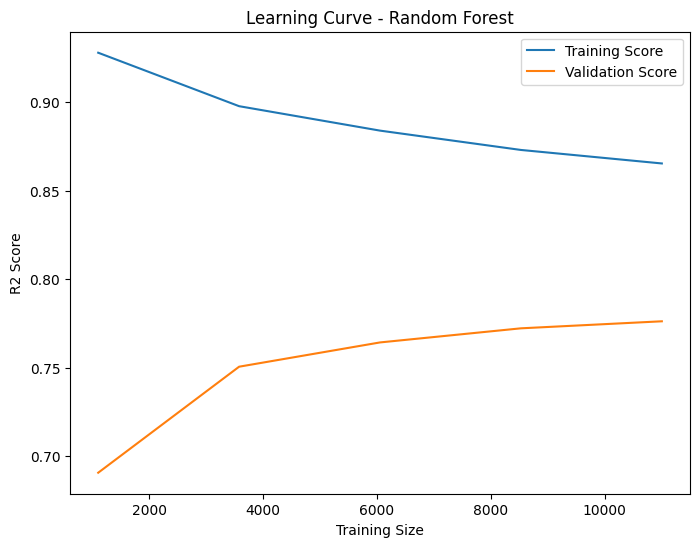

In [23]:
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import numpy as np

# Smaller Random Forest for faster learning curve
fast_forest = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

train_sizes, train_scores, test_scores = learning_curve(
    fast_forest,
    X_train,
    y_train,
    cv=3,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - Random Forest")
plt.legend()
plt.show()